<a href="https://colab.research.google.com/github/manavos/data402-final-project/blob/main/Predicting_Music_Genres.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Preprocessing

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Download latest version
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")
print("Path to dataset files:", path)

df = pd.read_csv(path + '/dataset.csv')

df.isnull().sum() #missing values

df.duplicated().sum() # duplicate rows

df['track_genre'].value_counts() # class distribution

df.describe()

Using Colab cache for faster access to the '-spotify-tracks-dataset' dataset.
Path to dataset files: /kaggle/input/-spotify-tracks-dataset


,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


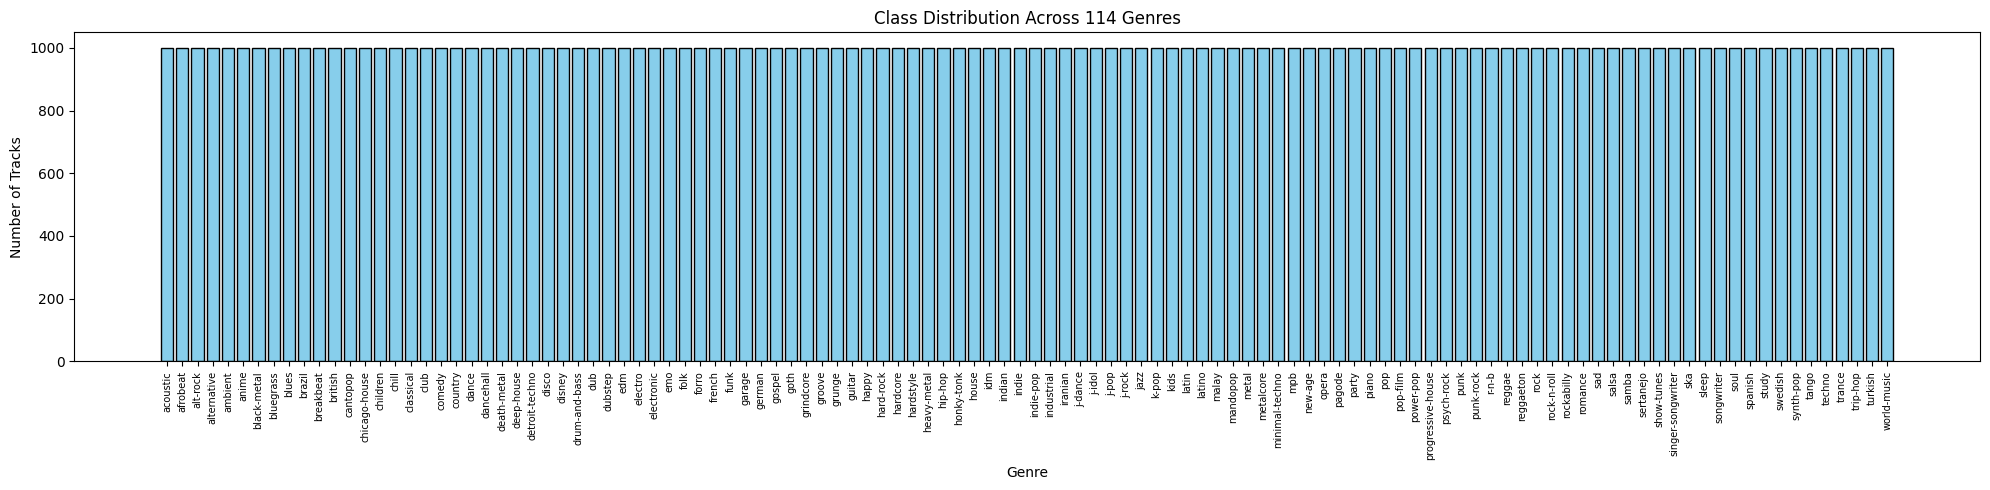

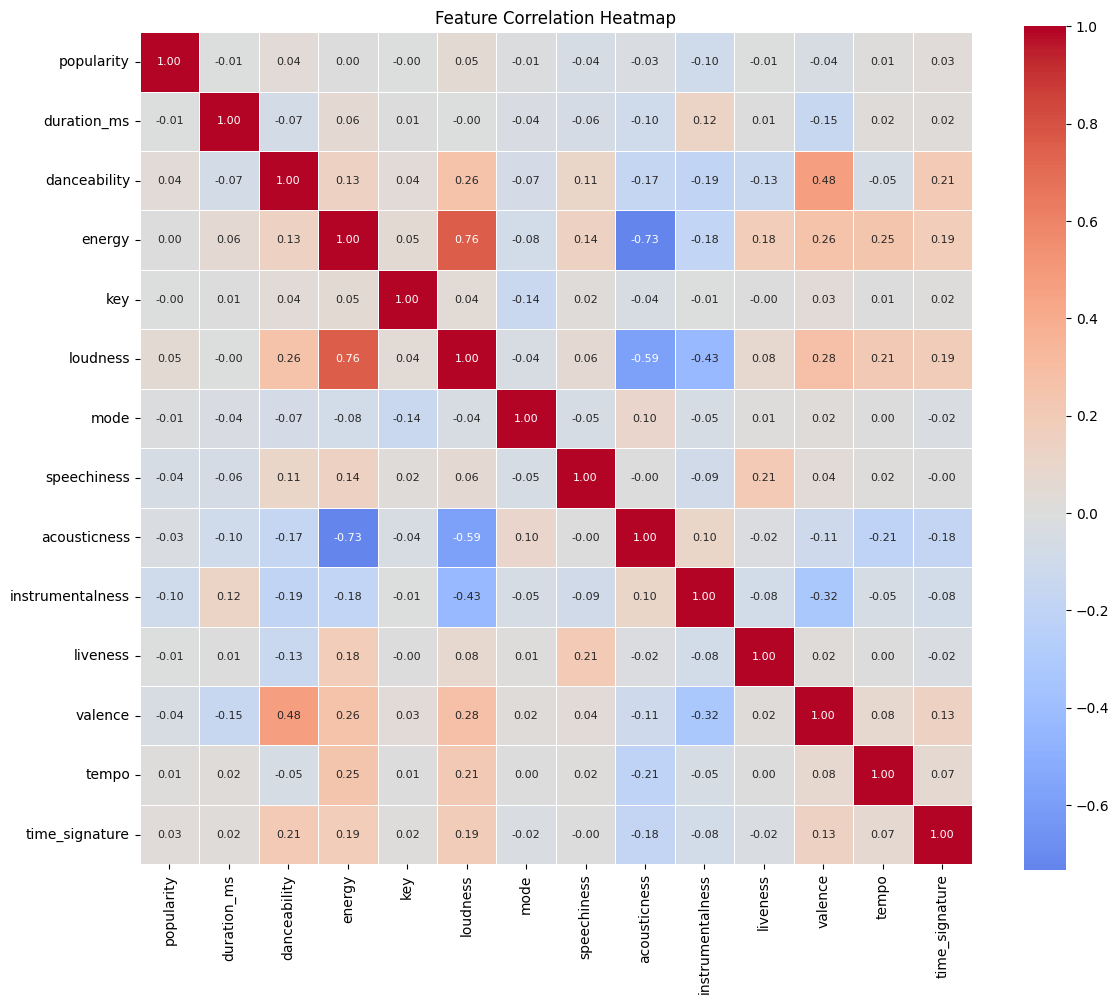

In [ ]:
import seaborn as sns

# Plot 1: Class Distribution
plt.figure(figsize=(20, 5))
genre_counts = df['track_genre'].value_counts().sort_index()
plt.bar(genre_counts.index, genre_counts.values, color='skyblue', edgecolor='black')
plt.title('Class Distribution Across 114 Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Tracks')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

# Plot 2: Feature Correlation Heatmap
feature_cols = ['popularity', 'duration_ms', 'danceability', 'energy', 'key',
                'loudness', 'mode', 'speechiness', 'acousticness',
                'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']

plt.figure(figsize=(12, 10))
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Visualizations

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Drop non-feature columns
X = df.drop(columns=['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'track_genre'])
y = df['track_genre']

# Scale and split
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr.predict(X_test)))

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_test, y_pred))

Accuracy: 0.20671052631578948
                   precision    recall  f1-score   support

         acoustic       0.11      0.08      0.09       213
         afrobeat       0.24      0.14      0.18       203
         alt-rock       0.00      0.00      0.00       215
      alternative       0.04      0.02      0.03       184
          ambient       0.32      0.35      0.33       197
            anime       0.02      0.01      0.01       193
      black-metal       0.36      0.45      0.40       210
        bluegrass       0.28      0.19      0.23       205
            blues       0.00      0.00      0.00       214
           brazil       0.10      0.03      0.05       197
        breakbeat       0.20      0.18      0.19       199
          british       0.00      0.00      0.00       214
         cantopop       0.17      0.17      0.17       193
    chicago-house       0.29      0.43      0.35       206
         children       0.23      0.36      0.28       214
            chill       0

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'track_genre'])
y = df['track_genre']

X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

svm = SVC(kernel='rbf', C=1.0, gamma='scale')
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

SVM Accuracy: 0.2768859649122807
                   precision    recall  f1-score   support

         acoustic       0.13      0.16      0.14       213
         afrobeat       0.28      0.19      0.23       203
         alt-rock       0.10      0.03      0.05       215
      alternative       0.13      0.08      0.10       184
          ambient       0.29      0.30      0.29       197
            anime       0.18      0.11      0.14       193
      black-metal       0.41      0.51      0.46       210
        bluegrass       0.42      0.40      0.41       205
            blues       0.16      0.07      0.10       214
           brazil       0.13      0.04      0.06       197
        breakbeat       0.21      0.20      0.20       199
          british       0.14      0.02      0.04       214
         cantopop       0.13      0.27      0.18       193
    chicago-house       0.37      0.56      0.44       206
         children       0.38      0.38      0.38       214
            chill     

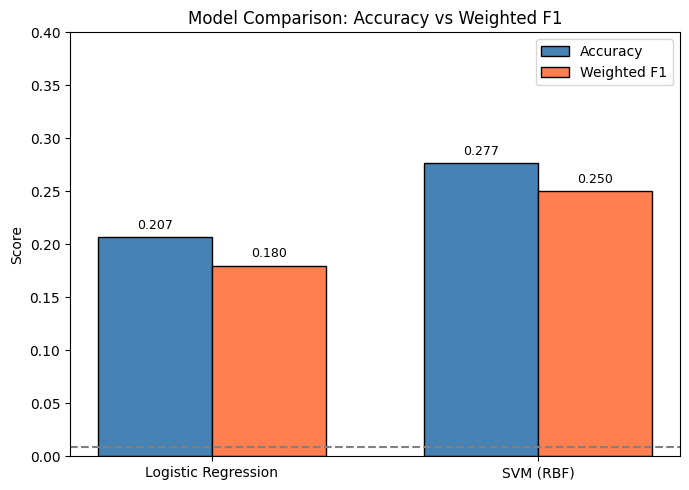

In [ ]:
models = ['Logistic Regression', 'SVM (RBF)']
accuracies = [0.2067, 0.2769]
weighted_f1 = [0.18, 0.25]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, weighted_f1, width, label='Weighted F1', color='coral', edgecolor='black')

ax.set_title('Model Comparison: Accuracy vs Weighted F1')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 0.40)
ax.legend()
ax.axhline(y=1/114, color='gray', linestyle='--', label='Random Baseline (~0.9%)')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, svm_preds, output_dict=True)
report_df = pd.DataFrame(report).T
report_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'])
report_df = report_df.sort_values('f1-score')

top10 = report_df.tail(10)
bot10 = report_df.head(10)
combined = pd.concat([bot10, top10])

colors = ['salmon'] * 10 + ['mediumseagreen'] * 10

plt.figure(figsize=(10, 8))
plt.barh(combined.index, combined['f1-score'], color=colors, edgecolor='black')
plt.title('SVM: Top 10 Best and Bottom 10 Worst Genres by F1 Score')
plt.xlabel('F1 Score')
plt.tight_layout()
plt.show()

NameError: name 'svm_preds' is not defined

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).T
report_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'])
report_df = report_df.sort_values('f1-score')

top10 = report_df.tail(10)
bot10 = report_df.head(10)
combined = pd.concat([bot10, top10])

colors = ['salmon'] * 10 + ['mediumseagreen'] * 10

plt.figure(figsize=(10, 8))
plt.barh(combined.index, combined['f1-score'], color=colors, edgecolor='black')
plt.title('Logistic Regression: Top 10 Best and Bottom 10 Worst Genres by F1 Score')
plt.xlabel('F1 Score')
plt.tight_layout()
plt.show()